# 🔬 EPFL Mitochondria Bioimage Segmentation with U-Net (PyTorch)
## 🎓 Deep Learning Applied to Bioimage Analysis (DLBA - PUCP)
**Instructor:** Gabriel Jiménez  
**Hardware:** Google Colab (GPU Acceleration: NVIDIA T4 / A100)  

---

### 📌 Contexto del Proyecto y Desafíos Bioimagen
1. **Dataset:** **EPFL Mitochondria** (Microscopía Electrónica de Transmisión - TEM, Hipocampo CA1 de ratón).
2. **Estructura Volumétrica:** Stack 3D de 165 cortes de $768 \times 1024$ píxeles (8-bit escala de grises, resolución $\sim 5\times 5\times 5\text{ nm/vóxel}$).
3. **Desafío Clave:** Fuerte desbalance de clases (las mitocondrias representan solo el **5.63%** del volumen; ratio **16.8:1** frente al fondo celular).
4. **Estrategia Metodológica:**
   - **Partición Z-Stack (80% Train / 20% Val):** Previene la fuga de información (*data leakage*) entre cortes 3D continuos.
   - **Extracción de Parches 2D:** Sub-imágenes de $256 \times 256$ píxeles.
   - **Aumentación Síncrona:** Rotaciones espaciales (90°, 180°, 270°) y reflexiones simétricas.
   - **Pérdida Compuesta:** $\mathcal{L}_{\text{BCE+Dice}} = 0.5\cdot \mathcal{L}_{\text{BCE}} + 1.0\cdot \mathcal{L}_{\text{Dice}}$ para optimizar directamente la morfología y mitigar el desbalance.
   - **Métricas Objetivo:** Coeficiente de Similitud Dice (DSC) e Intersección sobre Unión (IoU / Jaccard).

---
## ⚙️ Paso 1: Verificación de Hardware y Aceleración GPU

In [ ]:
# 1. Verificar disponibilidad de GPU en Colab
import torch
import sys
import os

print("=" * 65)
print("  VERIFICACIÓN DEL ENTORNO DE EJECUCIÓN (PYTORCH & GPU)")
print("=" * 65)
print(f"  * Versión de Python : {sys.version.split()[0]}")
print(f"  * Versión de PyTorch: {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
    gpu_name = torch.cuda.get_device_name(0)
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"  * GPU Detectada     : [OK] {gpu_name} ({vram_gb:.2f} GB VRAM)")
    print("  * Estado            : Listo para entrenamiento acelerado por hardware!")
else:
    device = torch.device("cpu")
    print("  * GPU Detectada     : [AVISO] No se detectó GPU. Corriendo en CPU.")
    print("    -> TIP: En Colab, ve a Entorno de Ejecución > Cambiar tipo de entorno > Selecciona T4 GPU.")
print("=" * 65)

  VERIFICACIÓN DEL ENTORNO DE EJECUCIÓN (PYTORCH & GPU)
  * Versión de Python : 3.12.13
  * Versión de PyTorch: 2.11.0+cu128
  * GPU Detectada     : [OK] Tesla T4 (14.56 GB VRAM)
  * Estado            : Listo para entrenamiento acelerado por hardware!


In [ ]:
# 2. Instalar dependencias científicas necesarias en Colab
!pip install -q tifffile scikit-image matplotlib pillow tqdm

---
## 📥 Paso 2: Descarga Automatizada del Dataset EPFL Mitochondria

In [ ]:
import urllib.request
import os
import tifffile
import numpy as np

DATA_DIR = "data/raw/epfl_mitochondria"
os.makedirs(DATA_DIR, exist_ok=True)

EPFL_BASE_URL = "https://documents.epfl.ch/groups/c/cv/cvlab-unit/www/data/%20ElectronMicroscopy_Hippocampus/"
DATASET_FILES = {
    "training_images": "training.tif",
    "training_masks": "training_groundtruth.tif",
}

def download_file(url: str, dest_path: str):
    if os.path.exists(dest_path):
        mb = os.path.getsize(dest_path) / (1024 * 1024)
        print(f"  [OK] Archivo ya presente: {os.path.basename(dest_path)} ({mb:.1f} MB)")
        return
    print(f"  [Descargando] {os.path.basename(dest_path)} desde el servidor EPFL...")
    req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(dest_path, 'wb') as out_file:
        total_size = int(response.headers.get('Content-Length', -1))
        downloaded = 0
        block_size = 1024 * 1024
        while True:
            chunk = response.read(block_size)
            if not chunk:
                break
            out_file.write(chunk)
            downloaded += len(chunk)
            if total_size > 0:
                print(f"\r    Progreso: {downloaded / total_size * 100:5.1f}% ({downloaded / (1024**2):.1f}/{total_size / (1024**2):.1f} MB)", end="")
    print("\n  [Completado] Descarga exitosa.")

for key, fname in DATASET_FILES.items():
    download_file(EPFL_BASE_URL + fname, os.path.join(DATA_DIR, fname))

# Cargar volúmenes 3D en memoria
image_volume = tifffile.imread(os.path.join(DATA_DIR, "training.tif"))
mask_volume = tifffile.imread(os.path.join(DATA_DIR, "training_groundtruth.tif"))

print("\n" + "=" * 65)
print("  ESTADÍSTICAS DEL VOLUMEN 3D (EPFL MITOCHONDRIA)")
print("=" * 65)
print(f"  * Dimensiones Stack Imágenes (Z, Y, X): {image_volume.shape} (dtype: {image_volume.dtype})")
print(f"  * Dimensiones Stack Máscaras (Z, Y, X): {mask_volume.shape} (dtype: {mask_volume.dtype})")

total_voxels = mask_volume.size
mito_voxels = int((mask_volume > 0).sum())
mito_ratio = (mito_voxels / total_voxels) * 100.0
bg_ratio = 100.0 - mito_ratio

print(f"  * Vóxeles de Mitocondrias (Clase 1) : {mito_voxels:,} ({mito_ratio:.2f}%)")
print(f"  * Vóxeles de Fondo (Clase 0)         : {total_voxels - mito_voxels:,} ({bg_ratio:.2f}%)")
print(f"  * Ratio de Desbalance (Fondo:Mito)   : {bg_ratio / mito_ratio:.1f} : 1")
print("=" * 65)

  [Descargando] training.tif desde el servidor EPFL...
    Progreso: 100.0% (123.9/123.9 MB)
  [Completado] Descarga exitosa.
  [Descargando] training_groundtruth.tif desde el servidor EPFL...
    Progreso: 100.0% (123.9/123.9 MB)
  [Completado] Descarga exitosa.

  ESTADÍSTICAS DEL VOLUMEN 3D (EPFL MITOCHONDRIA)
  * Dimensiones Stack Imágenes (Z, Y, X): (165, 768, 1024) (dtype: uint8)
  * Dimensiones Stack Máscaras (Z, Y, X): (165, 768, 1024) (dtype: uint8)
  * Vóxeles de Mitocondrias (Clase 1) : 7,306,042 (5.63%)
  * Vóxeles de Fondo (Clase 0)         : 122,455,238 (94.37%)
  * Ratio de Desbalance (Fondo:Mito)   : 16.8 : 1


---
## ✂️ Paso 3: Dataset PyTorch (`MitochondriaPatchDataset`) y DataLoaders

Implementamos la clase `Dataset` con:
1. **Extracción de parches 2D:** Tamaño $256 \times 256$.
2. **División Z-Stack (80% Train / 20% Val):**
   - **Train:** Cortes $0 \dots 131$ ($132$ cortes).
   - **Val:** Cortes $132 \dots 164$ ($33$ cortes).
3. **Data Augmentation Síncrono:** Rotaciones de 90°/180°/270° y Flips horizontales/verticales.

In [ ]:
import random
from typing import Tuple, List, Optional
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

class MitochondriaPatchDataset(Dataset):
    def __init__(
        self,
        images_volume: np.ndarray,
        masks_volume: np.ndarray,
        slice_indices: Optional[List[int]] = None,
        patch_size: int = 256,
        samples_per_epoch: Optional[int] = None,
        mode: str = "random",  # 'random' para entrenamiento, 'grid' para validación
        positive_oversample_prob: float = 0.5,
        transform: bool = True
    ):
        super().__init__()
        self.patch_size = patch_size
        self.mode = mode
        self.transform = transform
        self.positive_oversample_prob = positive_oversample_prob

        # Selección de cortes Z para evitar data leakage
        if slice_indices is not None:
            self.images = images_volume[slice_indices]
            self.masks = masks_volume[slice_indices]
        else:
            self.images = images_volume
            self.masks = masks_volume

        self.num_slices, self.height, self.width = self.images.shape

        if self.mode == "grid":
            # Grilla determinista sin solapamiento (12 parches por corte)
            self.grid_coords = []
            y_steps = self.height // patch_size
            x_steps = self.width // patch_size
            for s_idx in range(self.num_slices):
                for yi in range(y_steps):
                    for xi in range(x_steps):
                        y0 = yi * patch_size
                        x0 = xi * patch_size
                        self.grid_coords.append((s_idx, y0, x0))
            self.num_samples = len(self.grid_coords)
        else:
            self.num_samples = samples_per_epoch if samples_per_epoch is not None else self.num_slices * 12

    def __len__(self) -> int:
        return self.num_samples

    def _apply_synchronous_transforms(self, img_p: np.ndarray, mask_p: np.ndarray):
        # 1. Flip horizontal aleatorio
        if random.random() > 0.5:
            img_p = np.fliplr(img_p)
            mask_p = np.fliplr(mask_p)

        # 2. Flip vertical aleatorio
        if random.random() > 0.5:
            img_p = np.flipud(img_p)
            mask_p = np.flipud(mask_p)

        # 3. Rotaciones ortogonales (90, 180, 270 deg)
        if random.random() > 0.5:
            k = random.choice([1, 2, 3])
            img_p = np.rot90(img_p, k, axes=(0, 1))
            mask_p = np.rot90(mask_p, k, axes=(0, 1))

        return img_p.copy(), mask_p.copy()

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        if self.mode == "grid":
            s_idx, y0, x0 = self.grid_coords[idx]
            img_patch = self.images[s_idx, y0:y0 + self.patch_size, x0:x0 + self.patch_size]
            mask_patch = self.masks[s_idx, y0:y0 + self.patch_size, x0:x0 + self.patch_size]
        else:
            s_idx = random.randint(0, self.num_slices - 1)
            max_attempts = 10 if random.random() < self.positive_oversample_prob else 1
            best_y0, best_x0 = 0, 0

            for _ in range(max_attempts):
                y0 = random.randint(0, self.height - self.patch_size)
                x0 = random.randint(0, self.width - self.patch_size)
                cand_mask = self.masks[s_idx, y0:y0 + self.patch_size, x0:x0 + self.patch_size]
                if (cand_mask > 0).any():
                    best_y0, best_x0 = y0, x0
                    break
                best_y0, best_x0 = y0, x0

            img_patch = self.images[s_idx, best_y0:best_y0 + self.patch_size, best_x0:best_x0 + self.patch_size]
            mask_patch = self.masks[s_idx, best_y0:best_y0 + self.patch_size, best_x0:best_x0 + self.patch_size]

        # Normalización
        img_np = (img_patch.astype(np.float32) / 255.0)
        mask_np = (mask_patch.astype(np.float32) > 0.0).astype(np.float32)

        # Aumentación síncrona
        if self.transform:
            img_np, mask_np = self._apply_synchronous_transforms(img_np, mask_np)

        # Tensores de PyTorch [1, 256, 256]
        img_tensor = torch.from_numpy(img_np).unsqueeze(0).float()
        mask_tensor = torch.from_numpy(mask_np).unsqueeze(0).float()

        return img_tensor, mask_tensor


# Crear partición 80% Train / 20% Val
total_slices = image_volume.shape[0]
train_slices = list(range(0, int(total_slices * 0.8)))      # 132 cortes (0..131)
val_slices = list(range(int(total_slices * 0.8), total_slices)) # 33 cortes (132..164)

train_dataset = MitochondriaPatchDataset(
    image_volume, mask_volume, slice_indices=train_slices,
    samples_per_epoch=400, mode="random", positive_oversample_prob=0.6, transform=True
)

val_dataset = MitochondriaPatchDataset(
    image_volume, mask_volume, slice_indices=val_slices,
    mode="grid", transform=False
)

BATCH_SIZE = 16  # En GPU podemos usar batch size de 16 o 32 cómodamente
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=torch.cuda.is_available())

print(f"[OK] DataLoaders listos: Train = {len(train_dataset)} parches/época ({len(train_loader)} batches) | Val = {len(val_dataset)} parches ({len(val_loader)} batches)")

[OK] DataLoaders listos: Train = 400 parches/época (25 batches) | Val = 396 parches (25 batches)


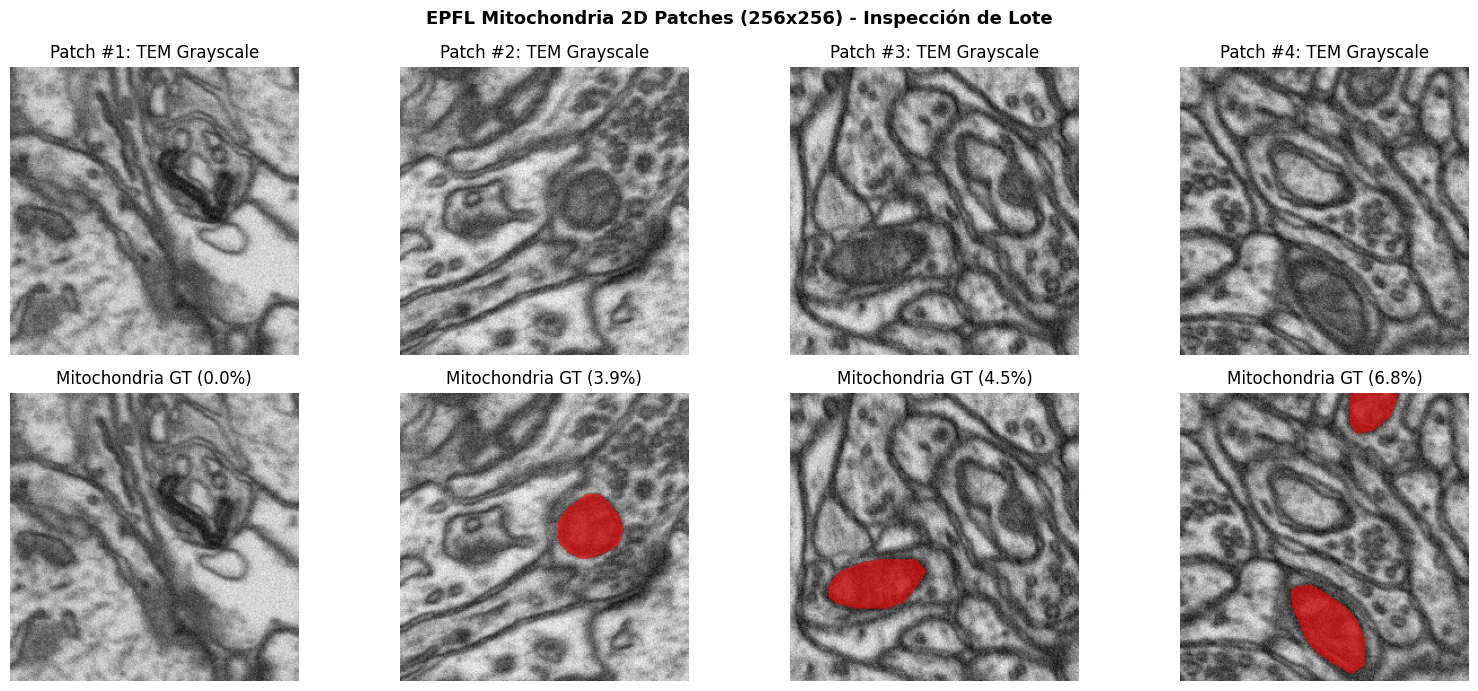

In [ ]:
# Visualizar un lote de parches de entrenamiento con Matplotlib
sample_imgs, sample_masks = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for i in range(4):
    img_np = sample_imgs[i, 0].numpy()
    mask_np = sample_masks[i, 0].numpy()

    # Fila 1: Imagen TEM en escala de grises
    axes[0, i].imshow(img_np, cmap='gray')
    axes[0, i].set_title(f"Patch #{i+1}: TEM Grayscale")
    axes[0, i].axis('off')

    # Fila 2: Sobreposición de Ground Truth
    axes[1, i].imshow(img_np, cmap='gray')
    mask_masked = np.ma.masked_where(mask_np < 0.5, mask_np)
    axes[1, i].imshow(mask_masked, cmap='autumn', alpha=0.6)
    mito_cov = (mask_np > 0.5).sum() / mask_np.size * 100.0
    axes[1, i].set_title(f"Mitochondria GT ({mito_cov:.1f}%)")
    axes[1, i].axis('off')

plt.suptitle("EPFL Mitochondria 2D Patches (256x256) - Inspección de Lote", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🏗️ Paso 4: Arquitectura U-Net 2D (1 Canal Entrada / 1 Canal Salida)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class DownBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.block(x)


class UpBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diff_y = x2.size()[2] - x1.size()[2]
        diff_x = x2.size()[3] - x1.size()[3]
        if diff_y != 0 or diff_x != 0:
            x1 = F.pad(x1, [diff_x // 2, diff_x - diff_x // 2, diff_y // 2, diff_y - diff_y // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels: int = 1, out_channels: int = 1, base_filters: int = 32):
        super().__init__()
        # Encoder
        self.inc = DoubleConv(in_channels, base_filters)
        self.down1 = DownBlock(base_filters, base_filters * 2)
        self.down2 = DownBlock(base_filters * 2, base_filters * 4)
        self.down3 = DownBlock(base_filters * 4, base_filters * 8)
        self.down4 = DownBlock(base_filters * 8, base_filters * 16) # Bottleneck

        # Decoder
        self.up1 = UpBlock(base_filters * 16, base_filters * 8)
        self.up2 = UpBlock(base_filters * 8, base_filters * 4)
        self.up3 = UpBlock(base_filters * 4, base_filters * 2)
        self.up4 = UpBlock(base_filters * 2, base_filters)

        self.outc = nn.Conv2d(base_filters, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        return self.outc(x)

model = UNet(in_channels=1, out_channels=1, base_filters=32).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"[OK] U-Net construida exitosamente en {device} | Total Parámetros: {total_params:,}")

[OK] U-Net construida exitosamente en cuda | Total Parámetros: 7,762,465


---
## 🎯 Paso 5: Funciones de Pérdida Compuesta (`BCE + Dice`) y Métricas

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(logits)
        p_flat = probs.view(-1)
        t_flat = targets.view(-1)
        intersection = (p_flat * t_flat).sum()
        cardinality = p_flat.sum() + t_flat.sum()
        dice = (2.0 * intersection + self.smooth) / (cardinality + self.smooth)
        return 1.0 - dice


class BCEDiceLoss(nn.Module):
    def __init__(self, alpha: float = 0.5, beta: float = 1.0):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        loss_bce = self.bce(logits, targets)
        loss_dice = self.dice(logits, targets)
        return self.alpha * loss_bce + self.beta * loss_dice


def compute_metrics(logits: torch.Tensor, targets: torch.Tensor, threshold: float = 0.5, eps: float = 1e-7):
    with torch.no_grad():
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        p = preds.view(-1)
        g = targets.view(-1)

        tp = (p * g).sum().item()
        fp = (p * (1.0 - g)).sum().item()
        fn = ((1.0 - p) * g).sum().item()

        dice = (2.0 * tp + eps) / (2.0 * tp + fp + fn + eps)
        iou = (tp + eps) / (tp + fp + fn + eps)
        precision = (tp + eps) / (tp + fp + eps)
        recall = (tp + eps) / (tp + fn + eps)

    return {"dice": dice, "iou": iou, "precision": precision, "recall": recall}

---
## 🚀 Paso 6: Bucle de Entrenamiento (100 Épocas con GPU)

In [ ]:
from tqdm.notebook import tqdm
import time

EPOCHS = 100
LEARNING_RATE = 1e-3
CHECKPOINT_PATH = "best_mitochondria_unet_colab.pth"

criterion = BCEDiceLoss(alpha=0.5, beta=1.0)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = {
    "train_loss": [], "val_loss": [],
    "train_dice": [], "val_dice": [],
    "train_iou": [], "val_iou": []
}

best_val_dice = -1.0
start_total_time = time.time()

print(f"Iniciando entrenamiento de {EPOCHS} épocas en {device}...")

for epoch in range(1, EPOCHS + 1):
    # 1. Fase de Entrenamiento
    model.train()
    train_loss, train_dice, train_iou = 0.0, 0.0, 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        m = compute_metrics(logits, masks)
        train_dice += m["dice"]
        train_iou += m["iou"]

    scheduler.step()

    # 2. Fase de Validación
    model.eval()
    val_loss, val_dice, val_iou = 0.0, 0.0, 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            logits = model(images)
            loss = criterion(logits, masks)

            val_loss += loss.item()
            m = compute_metrics(logits, masks)
            val_dice += m["dice"]
            val_iou += m["iou"]

    # Promedios
    ep_train_loss = train_loss / len(train_loader)
    ep_train_dice = train_dice / len(train_loader)
    ep_train_iou = train_iou / len(train_loader)

    ep_val_loss = val_loss / len(val_loader)
    ep_val_dice = val_dice / len(val_loader)
    ep_val_iou = val_iou / len(val_loader)

    history["train_loss"].append(ep_train_loss)
    history["val_loss"].append(ep_val_loss)
    history["train_dice"].append(ep_train_dice)
    history["val_dice"].append(ep_val_dice)
    history["train_iou"].append(ep_train_iou)
    history["val_iou"].append(ep_val_iou)

    # Guardar mejor modelo según Dice en Validación
    if ep_val_dice > best_val_dice:
        best_val_dice = ep_val_dice
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_dice': best_val_dice,
            'val_iou': ep_val_iou,
        }, CHECKPOINT_PATH)
        ckpt_flag = f"🔥 [NUEVO RÉCORD] Val Dice: {best_val_dice:.4f}"
    else:
        ckpt_flag = ""

    if epoch % 5 == 0 or epoch == 1 or epoch == EPOCHS:
        print(f"Época [{epoch:3d}/{EPOCHS}] | Train Loss: {ep_train_loss:.4f}, Dice: {ep_train_dice:.4f} | Val Loss: {ep_val_loss:.4f}, Dice: {ep_val_dice:.4f}, IoU: {ep_val_iou:.4f} {ckpt_flag}")

total_mins = (time.time() - start_total_time) / 60.0
print("\n" + "=" * 65)
print(f"  [ENTRENAMIENTO COMPLETADO EN {total_mins:.2f} MINUTOS]")
print(f"  * Mejor Coeficiente Dice en Validación (DSC): {best_val_dice:.4f}")
print(f"  * Checkpoint guardado en: '{CHECKPOINT_PATH}'")
print("=" * 65)

Iniciando entrenamiento de 100 épocas en cuda...
Época [  1/100] | Train Loss: 0.9836, Dice: 0.5820 | Val Loss: 3.9044, Dice: 0.0895, IoU: 0.0469 🔥 [NUEVO RÉCORD] Val Dice: 0.0895
Época [  5/100] | Train Loss: 0.4963, Dice: 0.8660 | Val Loss: 0.7069, Dice: 0.6699, IoU: 0.5132 
Época [ 10/100] | Train Loss: 0.1933, Dice: 0.9142 | Val Loss: 0.2554, Dice: 0.8655, IoU: 0.7645 🔥 [NUEVO RÉCORD] Val Dice: 0.8655
Época [ 15/100] | Train Loss: 0.1418, Dice: 0.9158 | Val Loss: 0.2633, Dice: 0.8161, IoU: 0.6952 
Época [ 20/100] | Train Loss: 0.1151, Dice: 0.9261 | Val Loss: 0.1648, Dice: 0.8889, IoU: 0.8046 
Época [ 25/100] | Train Loss: 0.1119, Dice: 0.9241 | Val Loss: 0.1587, Dice: 0.8800, IoU: 0.7875 
Época [ 30/100] | Train Loss: 0.0901, Dice: 0.9382 | Val Loss: 0.1281, Dice: 0.9035, IoU: 0.8259 
Época [ 35/100] | Train Loss: 0.0953, Dice: 0.9330 | Val Loss: 0.1372, Dice: 0.8944, IoU: 0.8113 
Época [ 40/100] | Train Loss: 0.0886, Dice: 0.9364 | Val Loss: 0.0955, Dice: 0.9274, IoU: 0.8654 🔥 [N

---
## 📈 Paso 7: Curvas de Aprendizaje y Dinámica de Convergencia

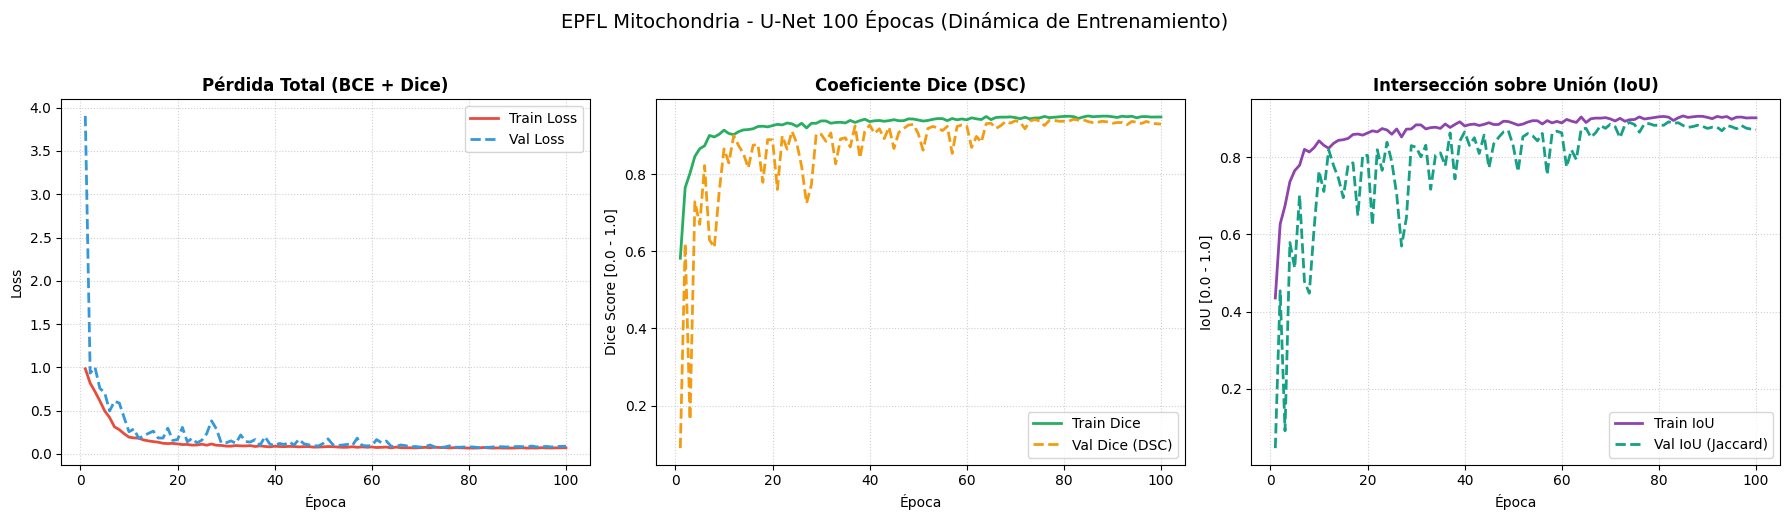

In [ ]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Pérdida (BCE + Dice)
axes[0].plot(epochs_range, history["train_loss"], color='#e74c3c', label='Train Loss', lw=2)
axes[0].plot(epochs_range, history["val_loss"], color='#3498db', label='Val Loss', lw=2, linestyle='--')
axes[0].set_title("Pérdida Total (BCE + Dice)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend()

# 2. Coeficiente de Similitud Dice (DSC)
axes[1].plot(epochs_range, history["train_dice"], color='#27ae60', label='Train Dice', lw=2)
axes[1].plot(epochs_range, history["val_dice"], color='#f39c12', label='Val Dice (DSC)', lw=2, linestyle='--')
axes[1].set_title("Coeficiente Dice (DSC)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Dice Score [0.0 - 1.0]")
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend()

# 3. Intersección sobre Unión (IoU / Jaccard)
axes[2].plot(epochs_range, history["train_iou"], color='#8e44ad', label='Train IoU', lw=2)
axes[2].plot(epochs_range, history["val_iou"], color='#16a085', label='Val IoU (Jaccard)', lw=2, linestyle='--')
axes[2].set_title("Intersección sobre Unión (IoU)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Época")
axes[2].set_ylabel("IoU [0.0 - 1.0]")
axes[2].grid(True, linestyle=':', alpha=0.6)
axes[2].legend()

plt.suptitle("EPFL Mitochondria - U-Net 100 Épocas (Dinámica de Entrenamiento)", fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig("mitochondria_colab_training_curves.png", dpi=300, bbox_inches='tight')
plt.show()

---
## 🔬 Paso 8: Evaluación Cualitativa de Segmentación (5 Columnas)

Cargamos el mejor checkpoint guardado y evaluamos predicciones sobre parches de validación (cortes Z no vistos en entrenamiento):
1. **Imagen TEM original**
2. **Máscara Ground Truth**
3. **Mapa continuo de probabilidad (Sigmoid)**
4. **Predicción binaria final (Umbral $\ge 0.5$)**
5. **Mapa de error diagnóstico (Verde: TP, Amarillo: FP, Rojo: FN)**

[OK] Checkpoint cargado exitosamente (Época 82, Val Dice: 0.9425)


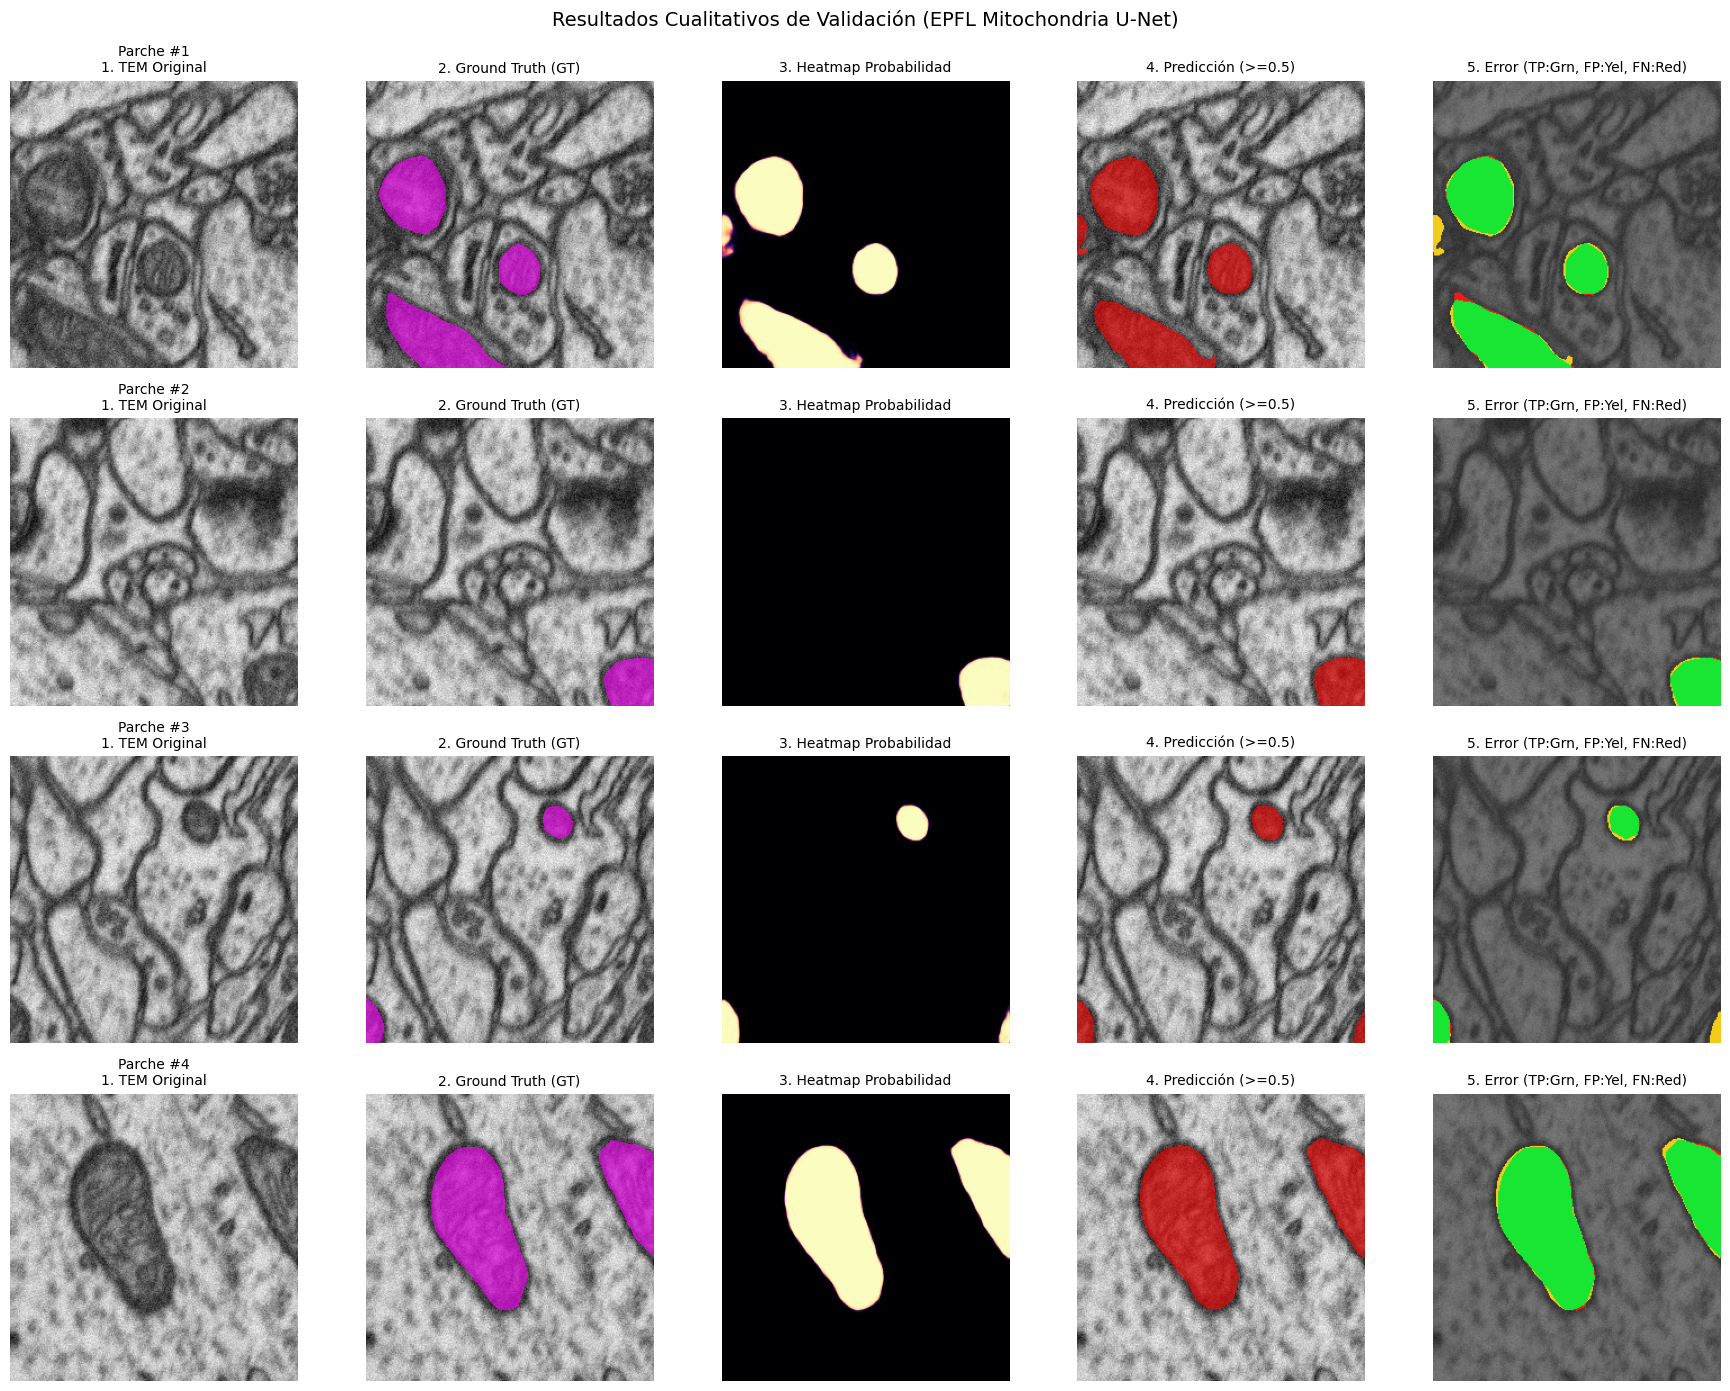

In [ ]:
# Cargar mejores pesos del modelo
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"[OK] Checkpoint cargado exitosamente (Época {checkpoint['epoch']}, Val Dice: {checkpoint['val_dice']:.4f})")

# Buscar parches representativos con presencia de mitocondrias
sample_indices = []
for idx in range(len(val_dataset)):
    _, mask_t = val_dataset[idx]
    if (mask_t > 0.5).sum() > 300:
        sample_indices.append(idx)
    if len(sample_indices) == 4:
        break

fig, axes = plt.subplots(4, 5, figsize=(18, 14))

with torch.no_grad():
    for row, idx in enumerate(sample_indices):
        img_t, mask_t = val_dataset[idx]
        inp_t = img_t.unsqueeze(0).to(device)

        logits = model(inp_t)
        prob = torch.sigmoid(logits).squeeze().cpu().numpy()
        pred_bin = (prob >= 0.5).astype(np.float32)

        img_np = img_t.squeeze().numpy()
        mask_np = mask_t.squeeze().numpy()

        # 1. TEM Grayscale
        axes[row, 0].imshow(img_np, cmap='gray')
        axes[row, 0].set_title(f"Parche #{idx}\n1. TEM Original", fontsize=10)
        axes[row, 0].axis('off')

        # 2. Ground Truth Overlay
        axes[row, 1].imshow(img_np, cmap='gray')
        gt_masked = np.ma.masked_where(mask_np < 0.5, mask_np)
        axes[row, 1].imshow(gt_masked, cmap='spring', alpha=0.6)
        axes[row, 1].set_title("2. Ground Truth (GT)", fontsize=10)
        axes[row, 1].axis('off')

        # 3. Probability Heatmap
        im3 = axes[row, 2].imshow(prob, cmap='magma', vmin=0.0, vmax=1.0)
        axes[row, 2].set_title("3. Heatmap Probabilidad", fontsize=10)
        axes[row, 2].axis('off')

        # 4. Predicción Binaria
        axes[row, 3].imshow(img_np, cmap='gray')
        pred_masked = np.ma.masked_where(pred_bin < 0.5, pred_bin)
        axes[row, 3].imshow(pred_masked, cmap='autumn', alpha=0.6)
        axes[row, 3].set_title("4. Predicción (>=0.5)", fontsize=10)
        axes[row, 3].axis('off')

        # 5. Mapa Diagnóstico de Error (Verde: TP, Amarillo: FP, Rojo: FN)
        err_map = np.zeros((256, 256, 3), dtype=np.float32)
        for c in range(3): err_map[..., c] = img_np * 0.6
        tp = (pred_bin == 1) & (mask_np == 1)
        fp = (pred_bin == 1) & (mask_np == 0)
        fn = (pred_bin == 0) & (mask_np == 1)
        err_map[tp] = [0.1, 0.9, 0.2]  # Verde (TP)
        err_map[fp] = [0.95, 0.8, 0.1] # Amarillo (FP)
        err_map[fn] = [0.95, 0.1, 0.1] # Rojo (FN)

        axes[row, 4].imshow(err_map)
        axes[row, 4].set_title("5. Error (TP:Grn, FP:Yel, FN:Red)", fontsize=10)
        axes[row, 4].axis('off')

plt.suptitle("Resultados Cualitativos de Validación (EPFL Mitochondria U-Net)", fontsize=14, y=0.99)
plt.tight_layout()
plt.savefig("mitochondria_colab_segmentation_results.png", dpi=300, bbox_inches='tight')
plt.show()

---
## 💾 Paso 9: Descargar Checkpoint y Figuras a tu Computadora

In [ ]:
# Código para descargar los archivos generados directamente desde Google Colab
try:
    from google.colab import files
    print("Descargando el modelo entrenado y las figuras a tu máquina...")
    files.download(CHECKPOINT_PATH)
    files.download("mitochondria_colab_training_curves.png")
    files.download("mitochondria_colab_segmentation_results.png")
    print("[OK] Descargas iniciadas!")
except ImportError:
    print("No estás en Google Colab. Los archivos se encuentran guardados en tu directorio local.")

Descargando el modelo entrenado y las figuras a tu máquina...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[OK] Descargas iniciadas!
